# **Laboratory 1 TDSE** - **Part 1**
Juan Sebastian Puentes Julio




# 1. **SETUP**

In [ ]:
%pip install numpy pandas matplotlib

# 2. **DATA SET VISUALIZATION**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#DATA SET
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])

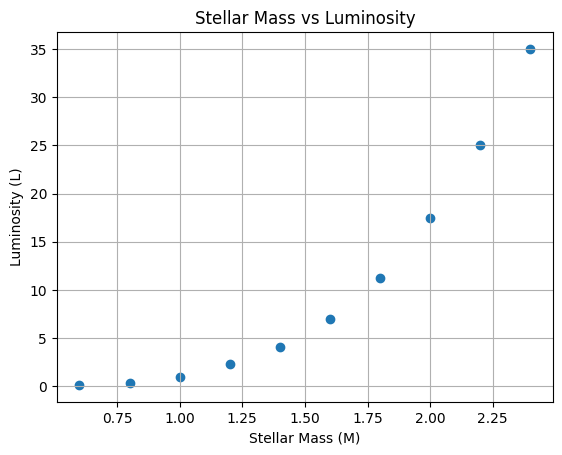

In [ ]:
plt.figure()
plt.scatter(M, L)
plt.xlabel("Stellar Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Stellar Mass vs Luminosity")
plt.grid(True)
plt.show()

The relationship between stellar mass and luminosity is nonlinear, and luminosity increases faster than mass. This behavior is evident in the curvature of the data, particularly for higher mass stars, where small increases in mass lead to large increases in luminosity.

# **3. MODEL AND LOSS**

In [ ]:
def predict(M, w, b):
    """Compute the predicted y values for given x, using f_{w,b}(x) = w x + b."""
    return w * M + b

In [ ]:
def compute_cost(M, L, w, b):
    m = M.shape[0]
    L_hat = predict(M,w,b)  # f_{w,b}(M)
    errors = L_hat - L
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

# **4. COST SURFACE**

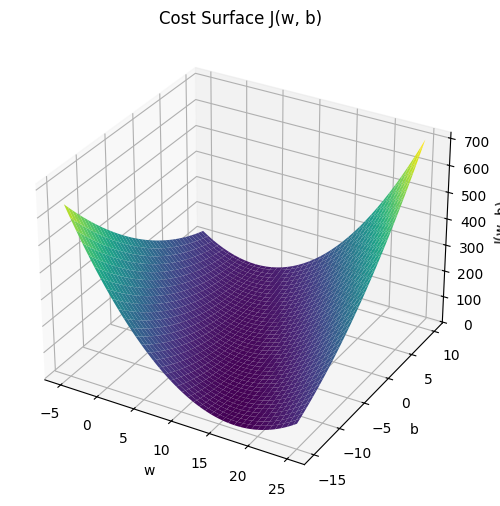

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

w_values = np.linspace(-5, 25, 120)
b_values = np.linspace(-15, 10, 120)

W, B = np.meshgrid(w_values, b_values)
J_vals = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_cost(M, L, W[i, j], B[i, j])

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0)

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w, b)")
ax.set_title("Cost Surface J(w, b)")

plt.show()


The minimum of the cost surface corresponds to the linear model that best fits the data, minimizing the average squared difference between predicted and observed luminosity.

# **5. GRADIENTS**

We use **gradient descent** with the update rules:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}, \quad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \quad
b := b - \alpha \frac{\partial J}{\partial b}
$$

In [ ]:
#Non - Vectorized
def compute_gradients_non_vectorized(x_list, y_list, w, b):
    """Compute dJ/dw and dJ/db using explicit loops."""
    m_local = len(x_list)
    sum_dw = 0.0
    sum_db = 0.0

    for i in range(m_local):
        f_wb = w * x_list[i] + b
        error = f_wb - y_list[i]
        sum_dw += error * x_list[i]
        sum_db += error

    dj_dw = sum_dw / m_local
    dj_db = sum_db / m_local
    return dj_dw, dj_db

w_test = 0.0
b_test = 0.0
dj_dw_test, dj_db_test = compute_gradients_non_vectorized(M, L, w_test, b_test)
print("Gradients at w=0, b=0:", dj_dw_test, dj_db_test)

Gradients at w=0, b=0: -21.523000000000003 -10.36


In [ ]:
#Vectorized
def compute_gradients(M, L, w, b):
    m = M.shape[0]
    L_hat = predict(M,w,b)  # f_{w,b}(M)
    errors = L_hat - L

    dj_dw = (1 / m) * np.sum(errors * M)
    dj_db = (1 / m) * np.sum(errors)

    return dj_dw, dj_db

dj_dw_test, dj_db_test = compute_gradients(M, L, w_test, b_test)
print("Gradients at w=0, b=0: ", dj_dw_test, dj_db_test)

Gradients at w=0, b=0:  -21.523 -10.36


# **6. GRADIENT DESCENT**

In [ ]:
def gradient_descent(M, L, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(M, L, w, b)
        history.append((i, cost))

        if i % max(1, (num_iterations // 10)) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")

    return w, b, history

alpha = 0.01
num_iterations = 3000

w_init = 0.0
b_init = 0.0

w_learned, b_learned, history = gradient_descent(M, L, w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)

Iteration    0: w= 0.2152, b= 0.1036, cost=112.0896
Iteration  300: w= 8.8900, b=-1.5257, cost= 24.9336
Iteration  600: w=11.1759, b=-5.3129, cost= 18.3703
Iteration  900: w=12.8962, b=-8.1632, cost= 14.6525
Iteration 1200: w=14.1910, b=-10.3085, cost= 12.5466
Iteration 1500: w=15.1655, b=-11.9231, cost= 11.3537
Iteration 1800: w=15.8989, b=-13.1383, cost= 10.6780
Iteration 2100: w=16.4509, b=-14.0528, cost= 10.2952
Iteration 2400: w=16.8663, b=-14.7412, cost= 10.0784
Iteration 2700: w=17.1790, b=-15.2592, cost=  9.9556

Learned parameters:
w = 17.41363618735943
b = -15.64802498207476


# **7. CONVERGENCE**


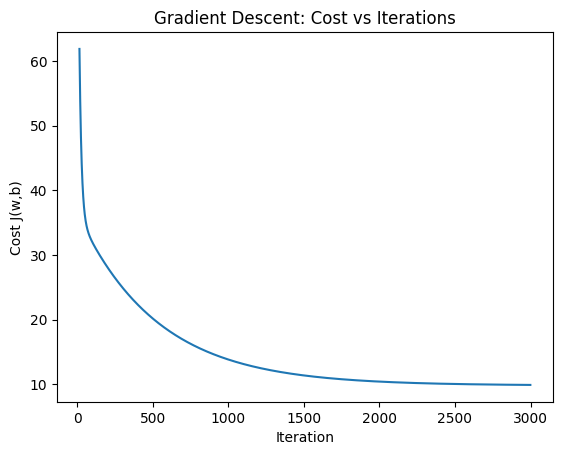

In [ ]:
iterations = [it for it, c in history]
costs = [c for it, c in history]

plt.figure()
plt.plot(iterations[15:], costs[15:])  # skip the first points
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent: Cost vs Iterations")
plt.show()

# **8. EXPERIMENTS**

In [ ]:
learning_rates = [0.001, 0.01, 0.05]

for alpha in learning_rates:
    w_f, b_f, J_hist = gradient_descent(M, L, 0, 0, alpha, 1000)
    print(f"alpha={alpha} → w={w_f:.3f}, b={b_f:.3f}, final loss={J_hist[-1][1]:.4f}")

Iteration    0: w= 0.0215, b= 0.0104, cost=117.1272
Iteration  100: w= 1.8528, b= 0.8539, cost= 76.1380
Iteration  200: w= 3.1775, b= 1.3941, cost= 55.5054
Iteration  300: w= 4.1445, b= 1.7209, cost= 45.0036
Iteration  400: w= 4.8589, b= 1.8976, cost= 39.5456
Iteration  500: w= 5.3949, b= 1.9691, cost= 36.6010
Iteration  600: w= 5.8048, b= 1.9668, cost= 34.9110
Iteration  700: w= 6.1253, b= 1.9130, cost= 33.8494
Iteration  800: w= 6.3826, b= 1.8233, cost= 33.1044
Iteration  900: w= 6.5950, b= 1.7088, cost= 32.5210
alpha=0.001 → w=6.774, b=1.579, final loss=32.0267
Iteration    0: w= 0.2152, b= 0.1036, cost=112.0896
Iteration  100: w= 6.8004, b= 1.5699, cost= 31.9704
Iteration  200: w= 7.9674, b=-0.0073, cost= 28.0913
Iteration  300: w= 8.8900, b=-1.5257, cost= 24.9336
Iteration  400: w= 9.7253, b=-2.9093, cost= 22.3208
Iteration  500: w=10.4849, b=-4.1680, cost= 20.1590
Iteration  600: w=11.1759, b=-5.3129, cost= 18.3703
Iteration  700: w=11.8044, b=-6.3543, cost= 16.8903
Iteration  80

# **9. FINAL FIT PLOT**

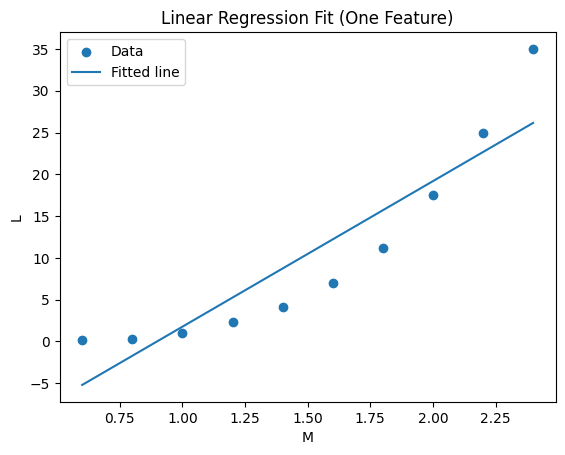

In [ ]:
plt.figure()
plt.scatter(M, L, label="Data")
y_pred = predict(M, w_learned, b_learned)
plt.plot(M, y_pred, label="Fitted line")
plt.xlabel("M")
plt.ylabel("L")
plt.title("Linear Regression Fit (One Feature)")
plt.legend()
plt.show()

The linear model systematically underestimates the luminosity of high-mass stars.

# **10. CONCEPTUAL QUESTIONS**


Astrophysical meaning of w?
- Represents how much stellar luminosity increases per unit increase in stellar mass.

Why is a linear model limited here?
- The linear model is limited because it is not able to accurately predict stellar luminosity across the entire mass range, particularly in the case of higher mass stars, where predictions deviate significantly from observed values. This indicates that the model is too simple and fails to capture the nonlinear behavior of the mass-luminosity relationship. Therefore, it is necessary to incorporate additional parameters or higher-order features to achieve more accurate predictions.
